In [ ]:
# Set vedo backend to VTK — required for Jupyter notebooks
from vedo import settings
settings.default_backend = "vtk"

# Import all spatchcocking utilities (includes getTightercmap, getAxis, etc.)
from spatchcocking import *

In [ ]:
# Discover all VTK mesh files in the meshes folder.
# Files are sorted: 3 × HH17 (indices 0-2) then 3 × HH20 (indices 3-5).
# Each VTK file contains a lumen surface mesh with pre-computed vertex arrays:
#   Gauss_Curvature, Mean_Curvature, K1, K2, thickness, phh3

import pathlib
import vedo

mesh_dir = pathlib.Path("../data/meshes")
all_vtk_files = sorted(mesh_dir.glob("*HH17.vtk")) + sorted(mesh_dir.glob("*HH20.vtk"))

# Cap at 6 files for the 2×3 subplot grid
files_to_show = all_vtk_files[:6]

print(files_to_show)

[WindowsPath('../data/meshes/2025-09-18-13-02-HH17.vtk'), WindowsPath('../data/meshes/2025-09-18-14-26-HH17.vtk'), WindowsPath('../data/meshes/2025-09-18-16-46-HH17.vtk'), WindowsPath('../data/meshes/2025-09-23-15-48-HH20.vtk'), WindowsPath('../data/meshes/2025-10-22-12-30-HH20.vtk'), WindowsPath('../data/meshes/2025-10-23-13-06-HH20.vtk')]


In [ ]:
# --- Parameters ---
file_index = 2  # which mesh to inspect: 0-2 = HH17, 3-5 = HH20
cmap_limit = 2  # sigma clipping: colour range is clipped at ±N std deviations
#                 lower = more contrast in the core distribution, outliers saturate

from vedo import Plotter, Mesh
import numpy as np

# Open a 2×3 grid of subplots, one panel per scalar field
plt = Plotter(N=6, axes=4, sharecam=True, size=(1800, 1000))
mesh1 = Mesh(all_vtk_files[file_index])

# Each tuple: (vertex array name, display title, colormap)
# Diverging colormaps (PiYG, Spectral_r) for signed quantities centred on 0.
# Sequential colormaps (GnBu, viridis) for non-negative quantities.
fields = [
    ("Gauss_Curvature", "Gaussian Curvature", "PiYG"),
    ("Mean_Curvature",  "Mean Curvature",      "PiYG"),
    ("thickness",       "Thickness",           "GnBu"),
    ("K1",              "Max Principal (K1)",  "Spectral_r"),
    ("K2",              "Min Principal (K2)",  "Spectral_r"),
    ("phh3",            "PHH3 Intensity",      "viridis"),
]

for i, (name, title, colormap) in enumerate(fields):
    if name in mesh1.pointdata.keys():
        msh_alt = mesh1.clone()
        data_values = msh_alt.pointdata[name]

        # Compute colour limits with sigma clipping (clips outlier vertices)
        vmin, vmax = getTightercmap(data_values, cmap_limit)

        # Curvatures are signed: force the range to be symmetric around 0
        # so that the neutral colour (white/centre) always maps to zero curvature
        if any(key in name for key in ["Curvature", "K1", "K2"]):
            vmax = max(abs(vmin), abs(vmax))
            vmin = -vmax

        # Thickness and pHH3 are non-negative: clamp floor to 0
        elif name in ["thickness", "phh3"]:
            vmin = 0

        msh_alt.cmap(colormap, name, vmin=vmin, vmax=vmax)
        msh_alt.add_scalarbar(title=title, label_format=":6.1e")

        plt.at(i).show(msh_alt, f"Field: {name}")
    else:
        plt.at(i).show(f"Data '{name}' not found")

# Render everything
plt.interactive().close()

vedo.plotter.runtime.Plotter
n. of objects : 12 (384006 vertices)
bounds        : x=(196, 992), y=(476, 2.17e+3), z=(1.21e+3, 2.70e+3)
axes style    : 4 (axes triad at bottom left)

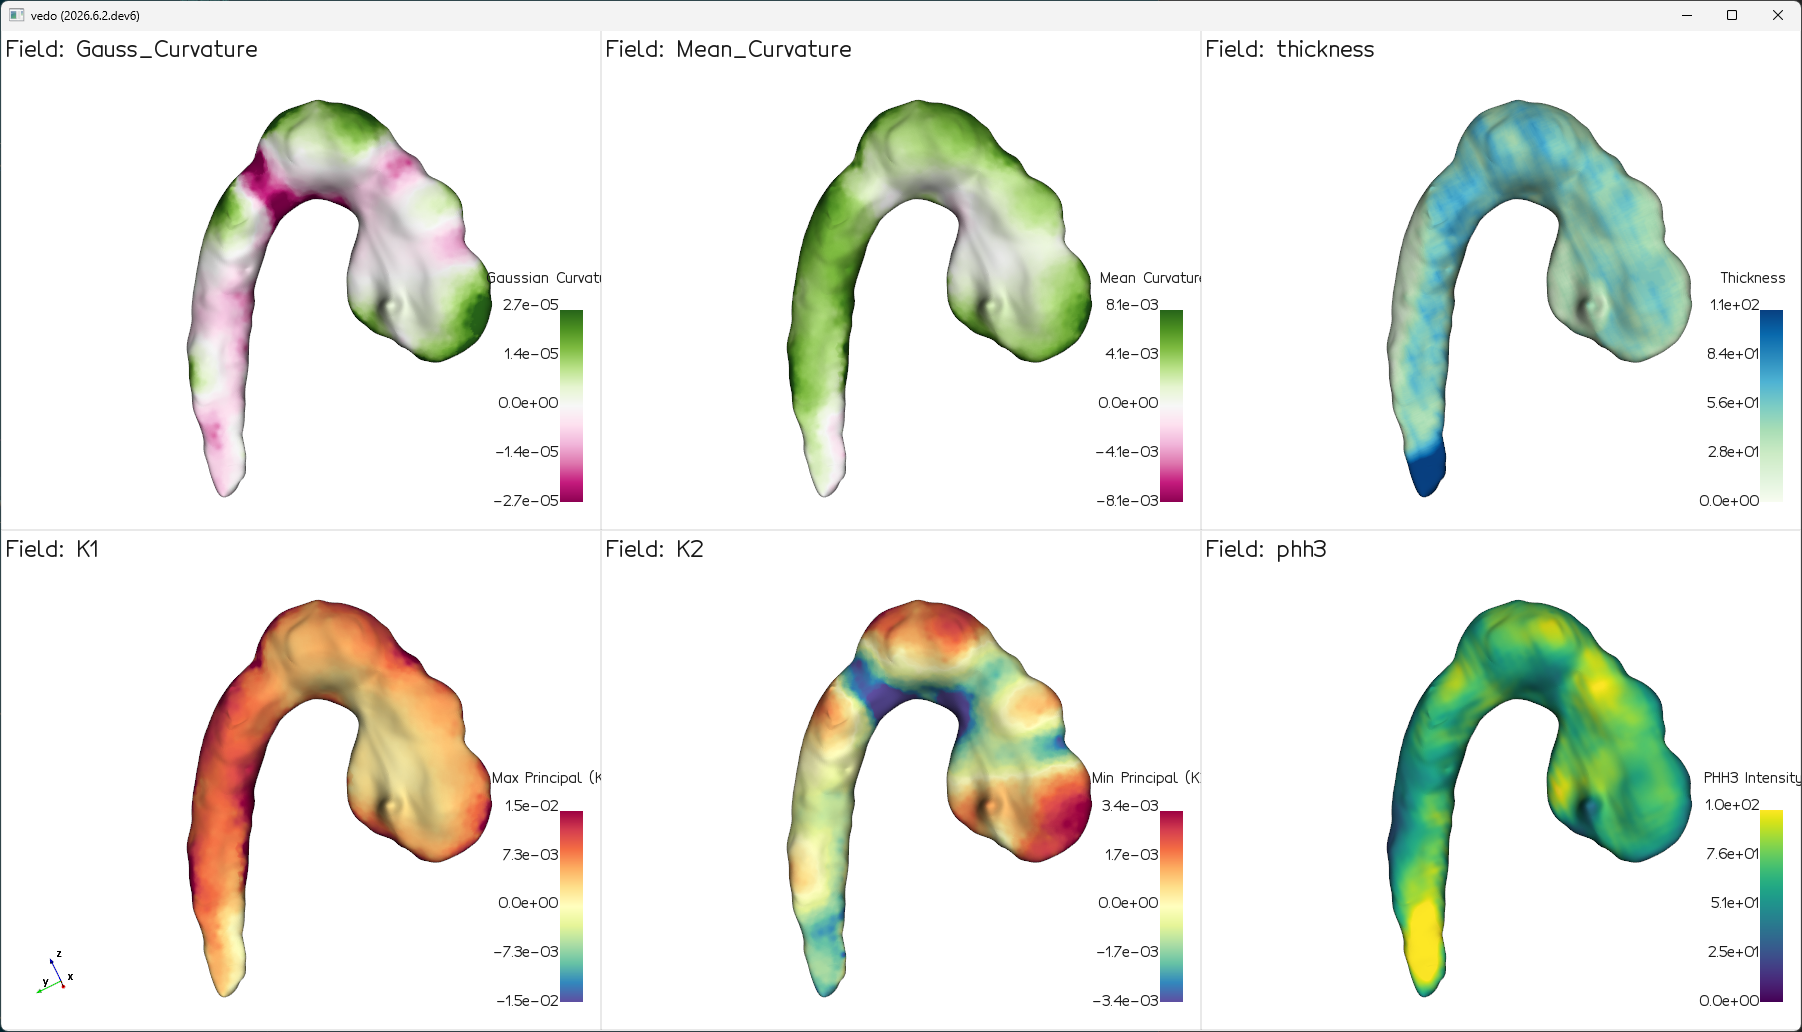

In [ ]:
# --- Parameters ---
file_index = 5  # which mesh to inspect: 0-2 = HH17, 3-5 = HH20
cmap_limit = 2  # sigma clipping: colour range is clipped at ±N std deviations
#                 lower = more contrast in the core distribution, outliers saturate

from vedo import Plotter, Mesh
import numpy as np

# Open a 2×3 grid of subplots, one panel per scalar field
plt = Plotter(N=6, axes=4, sharecam=True, size=(1800, 1000))
mesh1 = Mesh(all_vtk_files[file_index])

# Each tuple: (vertex array name, display title, colormap)
# Diverging colormaps (PiYG, Spectral_r) for signed quantities centred on 0.
# Sequential colormaps (GnBu, viridis) for non-negative quantities.
fields = [
    ("Gauss_Curvature", "Gaussian Curvature", "PiYG"),
    ("Mean_Curvature",  "Mean Curvature",      "PiYG"),
    ("thickness",       "Thickness",           "GnBu"),
    ("K1",              "Max Principal (K1)",  "Spectral_r"),
    ("K2",              "Min Principal (K2)",  "Spectral_r"),
    ("phh3",            "PHH3 Intensity",      "viridis"),
]

for i, (name, title, colormap) in enumerate(fields):
    if name in mesh1.pointdata.keys():
        msh_alt = mesh1.clone()
        data_values = msh_alt.pointdata[name]

        # Compute colour limits with sigma clipping (clips outlier vertices)
        vmin, vmax = getTightercmap(data_values, cmap_limit)

        # Curvatures are signed: force the range to be symmetric around 0
        # so that the neutral colour (white/centre) always maps to zero curvature
        if any(key in name for key in ["Curvature", "K1", "K2"]):
            vmax = max(abs(vmin), abs(vmax))
            vmin = -vmax

        # Thickness and pHH3 are non-negative: clamp floor to 0
        elif name in ["thickness", "phh3"]:
            vmin = 0

        msh_alt.cmap(colormap, name, vmin=vmin, vmax=vmax)
        msh_alt.add_scalarbar(title=title, label_format=":6.1e")

        plt.at(i).show(msh_alt, f"Field: {name}")
    else:
        plt.at(i).show(f"Data '{name}' not found")

# Render everything
plt.interactive().close()

vedo.plotter.runtime.Plotter
n. of objects : 12 (22596 vertices)
bounds        : x=(196, 1.78e+3), y=(692, 3.35e+3), z=(953, 4.59e+3)
axes style    : 4 (axes triad at bottom left)

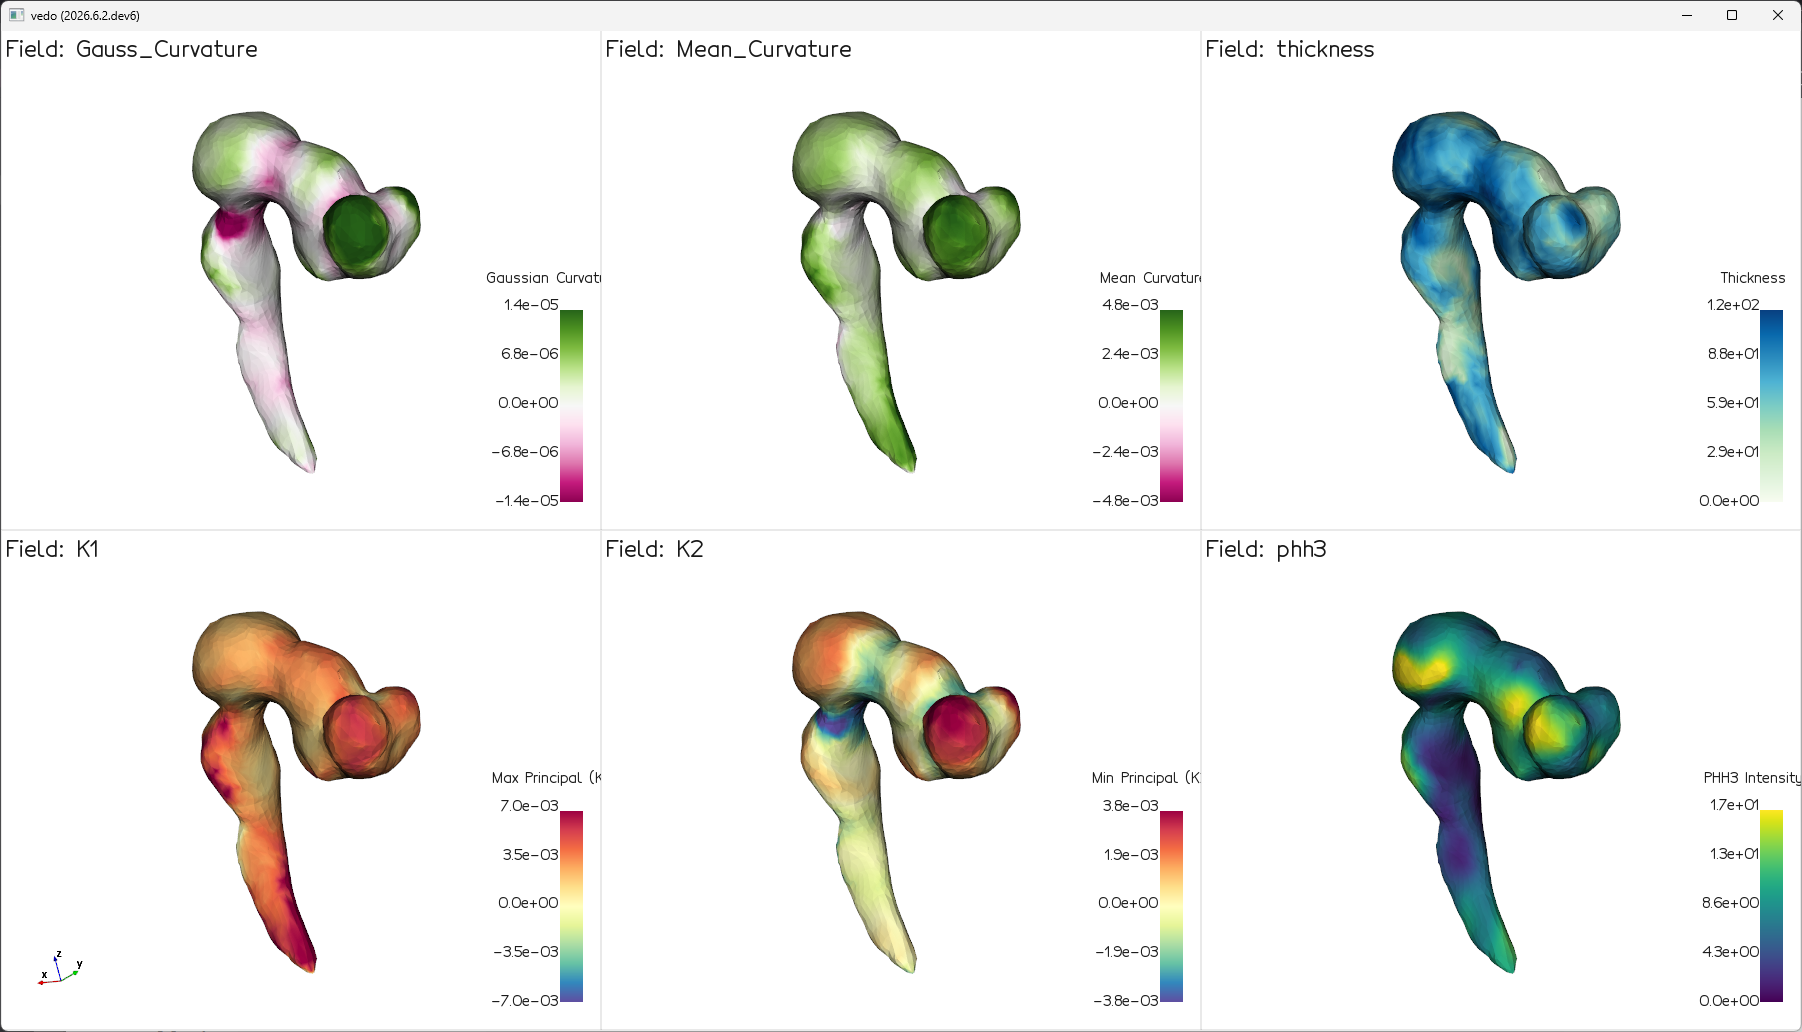